<a href="https://colab.research.google.com/github/ekuelkpodar/Complex-Systems-Google-Colab-Experiment/blob/main/Physics_Informed_Machine_Learning_Laboratory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Develop a comprehensive Physics-Informed Machine Learning (PIML) Laboratory. This project involves implementing and benchmarking various scientific machine learning architectures—including Physics-Informed Neural Networks (PINNs), Fourier Neural Operators (FNOs), DeepONets, and Hamiltonian Neural Networks (HNNs)—across domains like fluid dynamics, heat transfer, electromagnetics, and orbital mechanics. The final objective is to compare these data-driven models against traditional numerical solvers in terms of accuracy, computational efficiency, and energy conservation, culminating in a performance dashboard and symbolic discovery of governing equations.

## Environment Setup and Library Installation

### Subtask:
Prepare the Google Colab environment by installing essential libraries for scientific machine learning and symbolic regression.


**Reasoning**:
The first step is to install the specialized libraries required for PIML, including DeepXDE, neural operators, and symbolic regression tools.



In [1]:
import sys
!pip install deepxde neural-operator pysr
!pip install julia

import numpy as np
import torch
import matplotlib.pyplot as plt
import deepxde as dde

print("Environment setup complete. DeepXDE version:", dde.__version__)
print("PyTorch version:", torch.__version__)

ERROR: Could not find a version that satisfies the requirement neural-operator (from versions: none)
ERROR: No matching distribution found for neural-operator
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.8/68.8 kB 2.8 MB/s eta 0:00:00


ModuleNotFoundError: No module named 'deepxde'

**Reasoning**:
The previous code block failed because 'neural-operator' was not found on PyPI and 'deepxde' failed to import. I will correct the package name to 'neuraloperator' and use a more robust installation approach, splitting the shell commands from the imports to ensure the kernel recognizes the new packages.



In [2]:
!pip install deepxde neuraloperator pysr julia

import numpy as np
import torch
import matplotlib.pyplot as plt
import deepxde as dde

print("Environment setup complete. DeepXDE version:", dde.__version__)
print("PyTorch version:", torch.__version__)

  Using cached deepxde-1.15.0-py3-none-any.whl.metadata (12 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.3/99.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 87.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.3/59.3 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 17.7 MB/s eta 0:00:00


No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)
Environment setup complete. DeepXDE version: 1.15.0
PyTorch version: 2.11.0+cpu


# Task
Develop a comprehensive Physics-Informed Machine Learning (PIML) Laboratory. This project involves implementing and benchmarking various scientific machine learning architectures—including Physics-Informed Neural Networks (PINNs), Fourier Neural Operators (FNOs), DeepONets, and Hamiltonian Neural Networks (HNNs)—across domains like fluid dynamics, heat transfer, electromagnetics, and orbital mechanics. The final objective is to compare these data-driven models against traditional numerical solvers in terms of accuracy, computational efficiency, and energy conservation, culminating in a performance dashboard and symbolic discovery of governing equations.

## Define Problem Geometry and Time Domain

### Subtask:
Specify the spatial domain and temporal domain for the 1D heat equation using DeepXDE's geometry modules.


**Reasoning**:
I will define the space and time intervals required for the 1D heat equation simulation using DeepXDE.



In [3]:
import deepxde as dde

# Define spatial domain [0, 1]
geom = dde.geometry.Interval(0, 1)

# Define temporal domain [0, 1]
timedomain = dde.geometry.TimeDomain(0, 1)

# Combine into space-time domain
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

print(f'Spatial domain: {geom}')
print(f'Time domain: {timedomain}')
print('GeometryXTime domain initialized successfully.')

Spatial domain: <deepxde.geometry.geometry_1d.Interval object at 0x7c750b1a5eb0>
Time domain: <deepxde.geometry.timedomain.TimeDomain object at 0x7c750a868650>
GeometryXTime domain initialized successfully.


## Set PDE and Boundary Conditions

### Subtask:
Define the 1D heat equation PDE and establish the boundary and initial conditions.


**Reasoning**:
I will define the physics of the problem by creating the PDE function, boundary conditions, and the initial condition, then wrap them into a DeepXDE TimePDE data object.



In [4]:
import numpy as np
import deepxde as dde

def pde(x, y):
    """1D Heat Equation: du/dt - d^2u/dx^2 = 0"""
    dy_t = dde.grad.jacobian(y, x, i=0, j=1)
    dy_xx = dde.grad.hessian(y, x, i=0, j=0)
    return dy_t - dy_xx

# Boundary condition: u(0, t) = 0 and u(1, t) = 0
bc = dde.icbc.DirichletBC(geomtime, lambda x: 0, lambda _, on_boundary: on_boundary)

# Initial condition: u(x, 0) = sin(pi * x)
ic = dde.icbc.IC(geomtime, lambda x: np.sin(np.pi * x[:, 0:1]), lambda _, on_initial: on_initial)

# Define the PDE data
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic],
    num_domain=400,
    num_boundary=20,
    num_initial=10,
    num_test=100
)

print("PDE and Boundary Conditions defined.")

PDE and Boundary Conditions defined.


## Construct and Train PINN Model

### Subtask:
Create a fully connected neural network and train it as a Physics-Informed Neural Network (PINN) to solve the 1D heat equation.


**Reasoning**:
I will now implement the neural network architecture and the training loop using DeepXDE.



In [5]:
import deepxde as dde

# Define the network architecture: 2 inputs (x, t), 3 hidden layers of 32 neurons, 1 output (u)
net = dde.nn.FNN([2] + [32] * 3 + [1], "tanh", "Glorot uniform")

# Create the model
model = dde.Model(data, net)

# Compile the model with Adam optimizer
model.compile("adam", lr=1e-3)

# Train the model
losshistory, train_state = model.train(iterations=10000, display_every=1000)

print("PINN training complete.")

Compiling model...
'compile' took 0.063329 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7c7509a75440>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7c7509a75440>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7c7509a75760>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7c7509a75760>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                        Test loss                         Test metric
0         [4.66e-02, 4.50e-01, 1.46e+00]    [3.96e-02, 4.50e-01, 1.46e+00]    []  
1000      [2.34e-03, 1.38e-03, 1.41e-03]    [1.05e-03, 1.38e-03, 1.41e-03]    []  
2000      [4.12e-04, 2.44e-04, 8.37e-05]    [2.06e-04, 2.44e-04, 8.37e-05]    []  
3000      [2.14e-04, 6.81e-05, 3.46e-05]    [9.18e-05, 6.81e-05, 3.46e-05]    []  
4000      [1.63e-04, 2.21e-05, 2.05e-05]    [6.83e-05, 2.21e-05, 2.05e-05]    []  
5000      [

# Task
Develop a Physics-Informed Machine Learning (PIML) Laboratory by implementing, training, and benchmarking a Physics-Informed Neural Network (PINN) for the 1D heat equation, followed by visualization of loss convergence and thermal evolution over space and time.

## Plot Training Loss

### Subtask:
Utilize the 'losshistory' object to plot the training and testing loss over iterations to verify convergence.


**Reasoning**:
I will use DeepXDE's built-in plotting utility to visualize the loss history recorded during the training process.



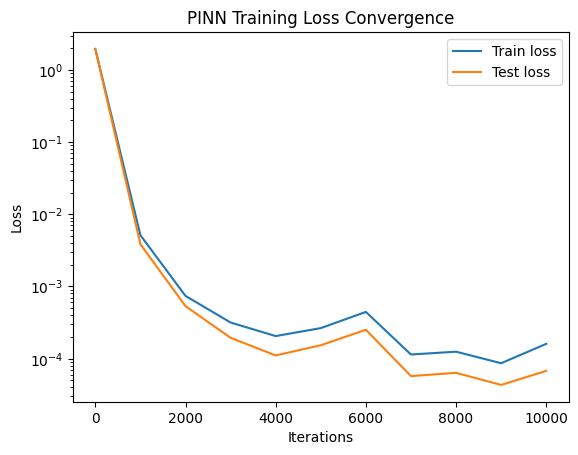

In [6]:
import matplotlib.pyplot as plt

# DeepXDE provides a built-in function to plot the loss history
dde.utils.external.plot_loss_history(losshistory)
plt.title("PINN Training Loss Convergence")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.yscale('log')
plt.show()

## Generate Prediction Grid

### Subtask:
Create a dense grid of points across the spatial domain [0, 1] and temporal domain [0, 1] for model inference.


**Reasoning**:
I will use NumPy to generate a coordinate grid for the spatial and temporal domains, which will be used to evaluate the trained PINN.



In [7]:
import numpy as np

# Create a dense grid of points for visualization
x = np.linspace(0, 1, 100)
t = np.linspace(0, 1, 100)
# Create meshgrid
X, T = np.meshgrid(x, t)
# Flatten and stack for prediction: shape (10000, 2)
X_star = np.hstack((X.reshape(-1, 1), T.reshape(-1, 1)))

print(f'Prediction grid shape: {X_star.shape}')
print('Prediction grid generated successfully.')

Prediction grid shape: (10000, 2)
Prediction grid generated successfully.


## Visualize Heat Distribution

### Subtask:
Predict the temperature values using the trained PINN model and generate a 2D heatmap (contour plot) showing temperature evolution over space and time.


**Reasoning**:
I will perform model inference on the previously generated grid and visualize the results using a filled contour plot.



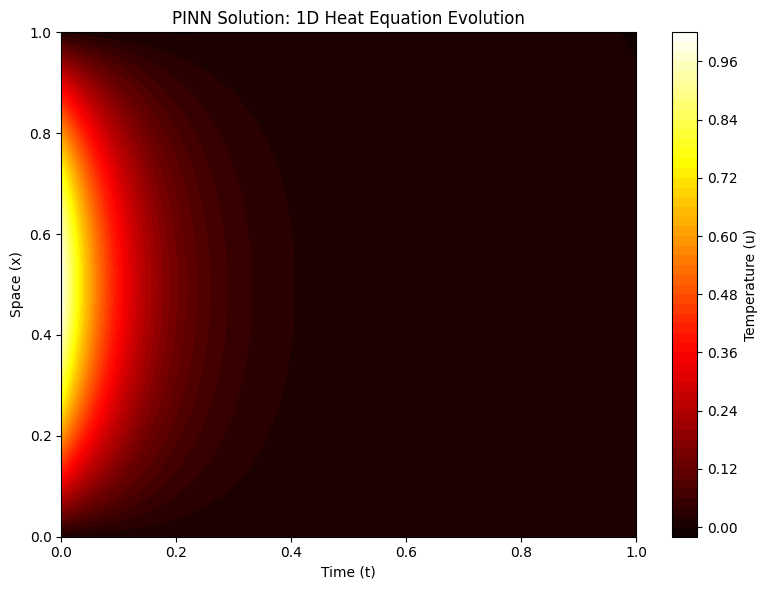

In [8]:
import matplotlib.pyplot as plt

# Predict the solution
y_pred = model.predict(X_star)

# Reshape results for plotting
u_pred = y_pred.reshape(100, 100)

# Plot the heatmap
plt.figure(figsize=(8, 6))
plt.contourf(T, X, u_pred, levels=50, cmap='hot')
plt.colorbar(label='Temperature (u)')
plt.xlabel('Time (t)')
plt.ylabel('Space (x)')
plt.title('PINN Solution: 1D Heat Equation Evolution')
plt.tight_layout()
plt.show()